# Verify, demonstrate, and preliminarily analyze M1

This notebook validates the persisted v9 M1 outputs, demonstrates the generated tables and figures, and provides a descriptive preliminary analysis of how M1 informs RQ1. It fails fast on invalid schemas, ranges, coverage, or v8 reproduction. The RQ1 analysis is exploratory and does not establish causality or actual AI adoption.

In [34]:
from pathlib import Path
import sys
import pandas as pd
import plotly.express as px
ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'paper_v9').is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from paper_v9.scripts.metrics.m1_rq1_perception_panel import QUESTION_ORDER
METRICS = ROOT / 'paper_v9' / 'data' / 'metrics'
FIGURES = ROOT / 'paper_v9' / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)


In [35]:
long = pd.read_csv(METRICS / 'm1_rq1_perception_panel_long.csv')
wide = pd.read_csv(METRICS / 'm1_rq1_perception_panel_wide.csv')
v8 = pd.read_csv(ROOT / 'paper_v8' / 'data' / 'm1_ai_dependency_trajectory.csv', dtype={'Semestre': str})
assert len(long) == 36
assert set(long['perception_family']) == set(QUESTION_ORDER)
assert long[['Semestre', 'temporal_marker', 'perception_family']].notna().all().all()
assert not long.duplicated(['Semestre', 'temporal_marker', 'perception_family']).any()
assert long['mean'].between(0, 4).all() and long['std'].ge(0).all()
assert long['n'].gt(0).all() and long['coverage'].between(0, 1).all()
assert long['coverage'].eq(1.0).all()
assert len(wide) == 6
print('schema, ranges, uniqueness, and coverage: PASS')


schema, ranges, uniqueness, and coverage: PASS


In [36]:
source = pd.read_parquet(ROOT / 'data' / 'analysis' / 'student_nlp.parquet')
assert source['question_id'].isin(QUESTION_ORDER).all()
recomputed = source.groupby(['Semestre', 'temporal_marker'], observed=True)['ai_dependency_score'].mean().reset_index(name='v8_recomputed')
comparison = recomputed.merge(v8, on=['Semestre', 'temporal_marker'], validate='one_to_one')
comparison['absolute_difference'] = (comparison['v8_recomputed'] - comparison['ai_dependency_composite_mean']).abs()
assert comparison['absolute_difference'].max() < 1e-12
assert v8['n_question_families_available'].eq(6).all()
comparison


,Semestre,temporal_marker,v8_recomputed,ai_dependency_composite_mean,n_question_families_available,absolute_difference
0,2025.2,T1,1.210145,1.210145,6,0.000000e+00
1,2025.2,T2,1.300813,1.300813,6,2.220446e-16
2,2025.2,T3,1.283333,1.283333,6,0.000000e+00
3,2026.1,T1,1.159091,1.159091,6,0.000000e+00
4,2026.1,T2,1.308333,1.308333,6,2.220446e-16
5,2026.1,T3,1.324074,1.324074,6,0.000000e+00


In [37]:
plot_data = long.copy()
plot_data['checkpoint_order'] = plot_data['temporal_marker'].map({'T1': 1, 'T2': 2, 'T3': 3})
trajectory = px.line(plot_data, x='temporal_marker', y='mean', color='perception_family', facet_col='Semestre', markers=True, category_orders={'temporal_marker': ['T1', 'T2', 'T3']}, title='M1 item trajectories')
distribution = px.histogram(long, x='mean', nbins=8, title='Distribution of M1 summaries')
trajectory_html = METRICS / 'm1_verification_trajectory.html'
distribution_html = METRICS / 'm1_verification_distribution.html'
trajectory.write_html(trajectory_html, include_plotlyjs='cdn')
distribution.write_html(distribution_html, include_plotlyjs='cdn')
for figure, stem in ((trajectory, 'm1_perception_trajectory'), (distribution, 'm1_perception_distribution')):
    for extension in ('pdf', 'svg', 'png'):
        figure.write_image(FIGURES / f'{stem}.{extension}', scale=2 if extension == 'png' else 1)

# Aggregate across semesters, retaining only the temporal marker as the time dimension.
temporal_only = (
    long.assign(weighted_sum=long['mean'] * long['n'])
    .groupby(['temporal_marker', 'perception_family'], as_index=False, observed=True)
    .agg(weighted_sum=('weighted_sum', 'sum'), n=('n', 'sum'), semester_count=('Semestre', 'nunique'))
)
temporal_only['mean'] = temporal_only['weighted_sum'] / temporal_only['n']
temporal_only = temporal_only.drop(columns='weighted_sum')
temporal_only['checkpoint_order'] = temporal_only['temporal_marker'].map({'T1': 1, 'T2': 2, 'T3': 3})
temporal_only = temporal_only.sort_values(['checkpoint_order', 'perception_family']).reset_index(drop=True)
assert 'Semestre' not in temporal_only.columns
assert len(temporal_only) == 18
assert temporal_only['mean'].between(0, 4).all()
temporal_only.to_csv(METRICS / 'm1_perception_temporal_only.csv', index=False)

temporal_trajectory = px.line(
    temporal_only,
    x='temporal_marker',
    y='mean',
    color='perception_family',
    markers=True,
    category_orders={'temporal_marker': ['T1', 'T2', 'T3']},
    title='M1 perceptions aggregated by temporal marker',
    labels={'mean': 'Weighted mean score (0-4)', 'temporal_marker': 'Temporal marker'},
)
temporal_heatmap = px.density_heatmap(
    temporal_only,
    x='temporal_marker',
    y='perception_family',
    z='mean',
    histfunc='avg',
    category_orders={'temporal_marker': ['T1', 'T2', 'T3'], 'perception_family': list(QUESTION_ORDER)},
    title='M1 perception means by temporal marker',
    labels={'mean': 'Weighted mean score (0-4)'},
    text_auto='.2f',
)
temporal_html_outputs = {
    'trajectory': METRICS / 'm1_verification_temporal_only_trajectory.html',
    'heatmap': METRICS / 'm1_verification_temporal_only_heatmap.html',
}
temporal_trajectory.write_html(temporal_html_outputs['trajectory'], include_plotlyjs='cdn')
temporal_heatmap.write_html(temporal_html_outputs['heatmap'], include_plotlyjs='cdn')
for figure, stem in (
    (temporal_trajectory, 'm1_perception_temporal_only_trajectory'),
    (temporal_heatmap, 'm1_perception_temporal_only_heatmap'),
):
    for extension in ('pdf', 'svg', 'png'):
        figure.write_image(FIGURES / f'{stem}.{extension}', scale=2 if extension == 'png' else 1)

temporal_static_outputs = [
    FIGURES / f'{stem}.{extension}'
    for stem in ('m1_perception_temporal_only_trajectory', 'm1_perception_temporal_only_heatmap')
    for extension in ('pdf', 'svg', 'png')
]
static_outputs = [
    FIGURES / f'{stem}.{extension}'
    for stem in ('m1_perception_trajectory', 'm1_perception_distribution')
    for extension in ('pdf', 'svg', 'png')
]
assert trajectory_html.is_file() and trajectory_html.stat().st_size > 0
assert distribution_html.is_file() and distribution_html.stat().st_size > 0
assert all(path.is_file() and path.stat().st_size > 0 for path in static_outputs)
assert all(path.is_file() and path.stat().st_size > 0 for path in temporal_html_outputs.values())
assert all(path.is_file() and path.stat().st_size > 0 for path in temporal_static_outputs)
print('interactive and article-ready plots written, including temporal-marker-only aggregates')


/home/amg/projects/uece/Do-We-Still-Need-to-Be-Agile/.venv/lib/python3.11/site-packages/plotly/express/_core.py:2065: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



interactive and article-ready plots written, including temporal-marker-only aggregates


In [41]:
metadata = pd.read_json(METRICS / 'm1_rq1_perception_panel.metadata.json', typ='series')
assert metadata['status'] == 'success'
assert metadata['gate_status'] == 'approved'
assert metadata['gate_approved_on'] == '2026-09-24'
assert set(metadata['unavailable_not_measured']) == {'individual_T1_T3_panel', 'team_semester'}
assert set(metadata['available_and_extracted']) == {
    'real_ai_use_frequency',
    'real_ai_use_tasks',
    'real_ai_use_tools',
    'prior_ai_project_experience',
    'autonomy_tool_balance',
}
assert metadata['exploratory_unvalidated'] == ['career_impact_topics']
print('approved descriptive M1 v2 contract and measurement boundaries: PASS')

approved descriptive M1 v2 contract and measurement boundaries: PASS


,Semestre,temporal_marker,perception_family,mean,n,coverage
0,2025.2,T1,ai_benefit,2.130435,46,1.0
1,2025.2,T1,autonomy_tool_dependency,3.086957,46,1.0
2,2025.2,T1,ai_career_impact_5y,1.478261,46,1.0
3,2025.2,T1,career_expectation,0.195652,46,1.0
4,2025.2,T1,project_challenges,0.260870,46,1.0
5,2025.2,T1,project_feeling,0.108696,46,1.0
6,2025.2,T2,ai_benefit,2.219512,41,1.0
7,2025.2,T2,autonomy_tool_dependency,3.024390,41,1.0
8,2025.2,T2,ai_career_impact_5y,1.439024,41,1.0
9,2025.2,T2,career_expectation,0.634146,41,1.0


,Semestre,temporal_marker,measure,category,count,respondent_n,share
4,2025.2,T1,general_frequency,Diariamente,19,46,0.413043
9,2025.2,T2,general_frequency,Diariamente,19,41,0.463415
14,2025.2,T3,general_frequency,Diariamente,18,40,0.450000
19,2026.1,T1,general_frequency,Diariamente,12,22,0.545455
24,2026.1,T2,general_frequency,Diariamente,13,20,0.650000
29,2026.1,T3,general_frequency,Diariamente,11,18,0.611111


,Semestre,temporal_marker,measure,category,count,respondent_n,share
7,2025.2,T1,real_ai_use_tasks,Pesquisa / Perguntas gerais / Uso anon_ccabe18...,42,46,0.913043
27,2025.2,T3,real_ai_use_tasks,Geração de código,31,40,0.775000
5,2025.2,T1,real_ai_use_tasks,Geração de código,30,46,0.652174
28,2025.2,T3,real_ai_use_tasks,Pesquisa / Perguntas gerais / Uso anon_ccabe18...,29,40,0.725000
18,2025.2,T2,real_ai_use_tasks,Geração de código,29,41,0.707317
19,2025.2,T2,real_ai_use_tasks,Pesquisa / Perguntas gerais / Uso anon_ccabe18...,28,41,0.682927
2,2025.2,T1,real_ai_use_tasks,Depuração / debug,27,46,0.586957
1,2025.2,T1,real_ai_use_tasks,Brainstorming de ideias,26,46,0.565217
23,2025.2,T3,real_ai_use_tasks,Brainstorming de ideias,25,40,0.625000
16,2025.2,T2,real_ai_use_tasks,Documentação,23,41,0.560976


,Semestre,temporal_marker,measure,category,count,respondent_n,share
0,2025.2,T1,real_ai_use_tools,ChatGPT,46,46,1.000000
13,2025.2,T2,real_ai_use_tools,ChatGPT,40,41,0.975610
27,2025.2,T3,real_ai_use_tools,ChatGPT,40,40,1.000000
4,2025.2,T1,real_ai_use_tools,Gemini,34,46,0.739130
17,2025.2,T2,real_ai_use_tools,Gemini,32,41,0.780488
31,2025.2,T3,real_ai_use_tools,Gemini,31,40,0.775000
3,2025.2,T1,real_ai_use_tools,DeepSeek,31,46,0.673913
16,2025.2,T2,real_ai_use_tools,DeepSeek,29,41,0.707317
30,2025.2,T3,real_ai_use_tools,DeepSeek,26,40,0.650000
39,2026.1,T1,real_ai_use_tools,ChatGPT,19,22,0.863636


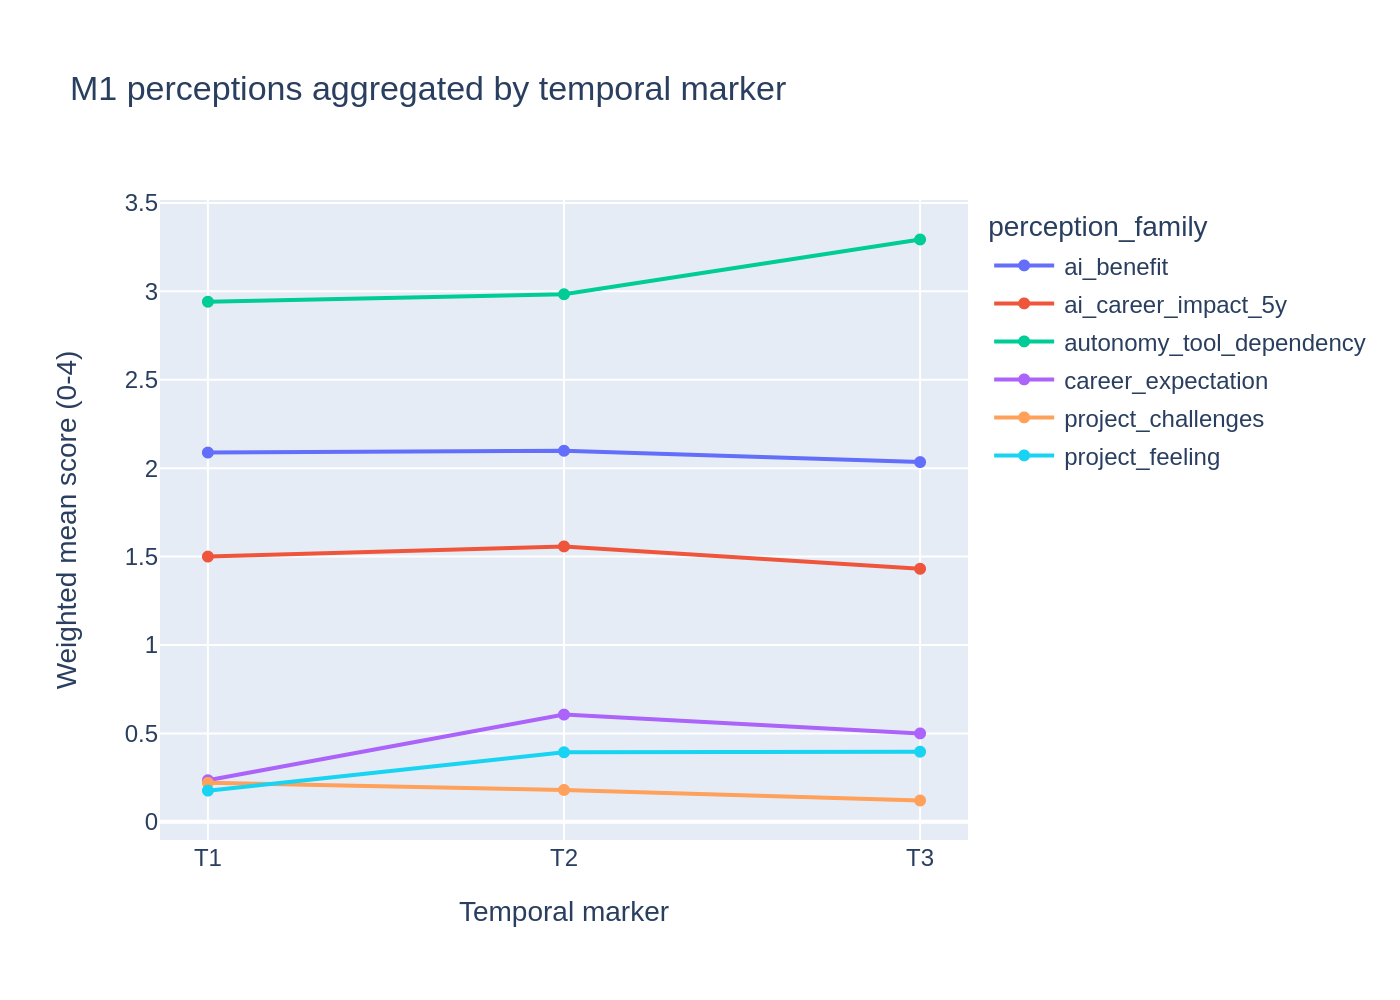

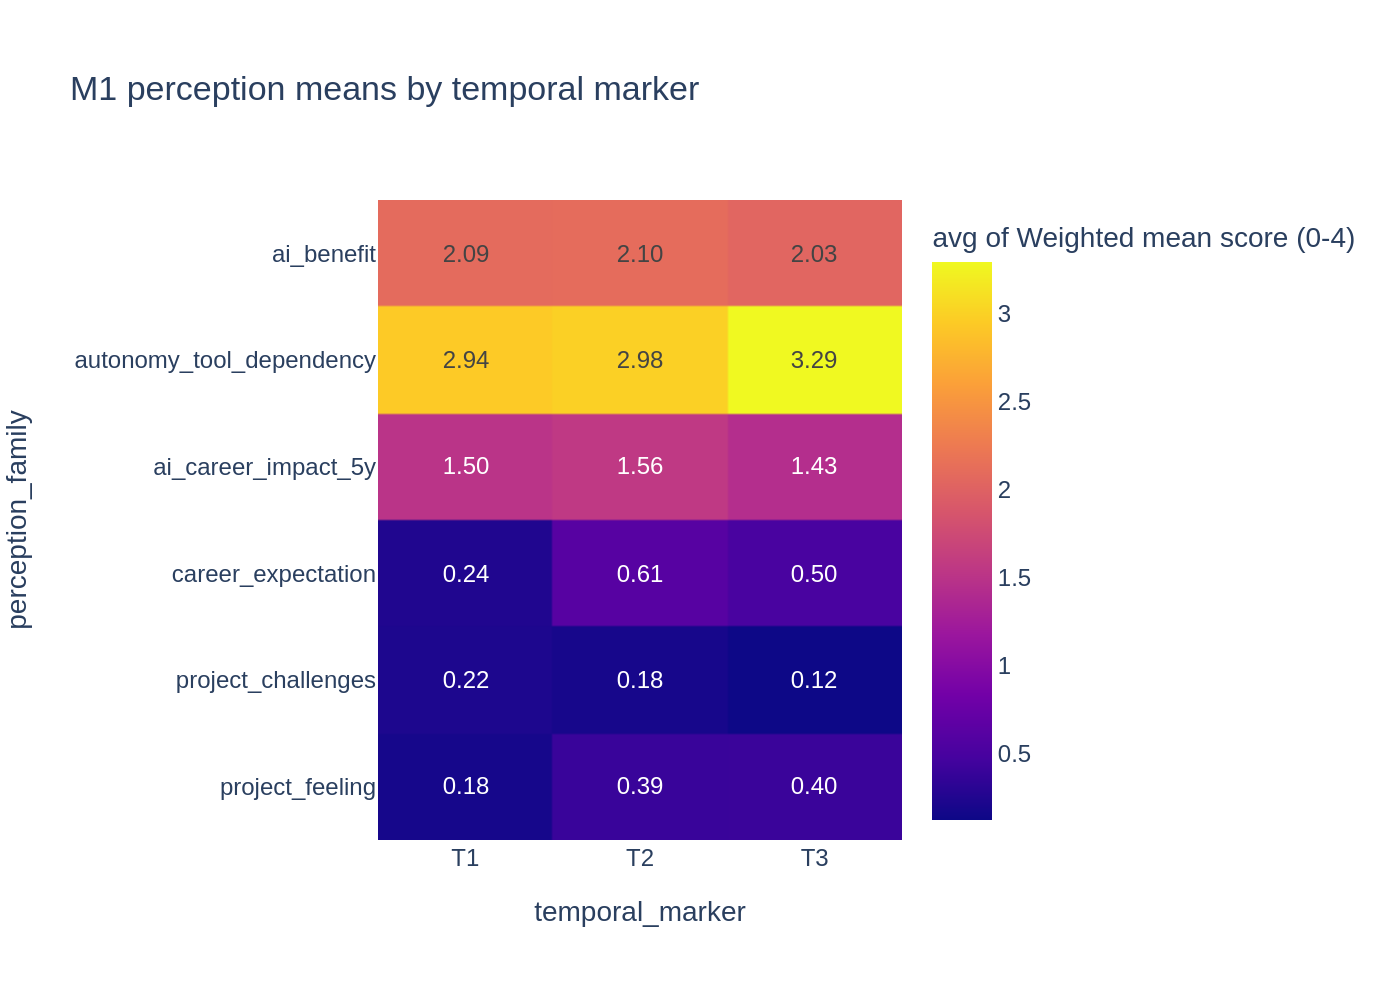

artifact demo: perception, usage tables, exploratory career topics, and figures displayed


In [39]:
from IPython.display import Image, display

usage_frequency = pd.read_csv(METRICS / 'm1_rq1_usage_frequency.csv')
usage_tasks = pd.read_csv(METRICS / 'm1_rq1_usage_tasks.csv')
usage_tools = pd.read_csv(METRICS / 'm1_rq1_usage_tools.csv')
career_topics = pd.read_csv(METRICS / 'm1_rq1_career_impact_topics_exploratory.csv')
artifact_preview = long[['Semestre', 'temporal_marker', 'perception_family', 'mean', 'n', 'coverage']].head(12)
display(artifact_preview)
display(usage_frequency.query("category == 'Diariamente'").head(6))
display(usage_tasks.sort_values('count', ascending=False).head(10))
display(usage_tools.sort_values('count', ascending=False).head(10))
assert career_topics['coding_status'].eq('exploratory_rule_based_unvalidated').all()
for figure_path in (
    FIGURES / 'm1_perception_temporal_only_trajectory.png',
    FIGURES / 'm1_perception_temporal_only_heatmap.png',
):
    assert figure_path.is_file() and figure_path.stat().st_size > 0
    display(Image(filename=str(figure_path), width=900))
print('artifact demo: perception, usage tables, exploratory career topics, and figures displayed')

## Artifact demo and preliminary RQ1 analysis

The next cells display representative perception and usage tables, exploratory career-topic coding, and generated article-ready figures. They also summarize descriptive T1-to-T3 changes by perception family. These outputs support inspection and hypothesis formation; they are not causal tests. Career-topic coding is explicitly unvalidated until human agreement is assessed.

In [40]:
t1_t3 = temporal_only[temporal_only['temporal_marker'].isin(['T1', 'T3'])].pivot(
    index='perception_family', columns='temporal_marker', values='mean'
).reset_index()
t1_t3['descriptive_change_T3_minus_T1'] = t1_t3['T3'] - t1_t3['T1']
assert t1_t3[['T1', 'T3', 'descriptive_change_T3_minus_T1']].notna().all().all()
display(t1_t3.sort_values('descriptive_change_T3_minus_T1', ascending=False))
software_daily = usage_frequency.query("measure == 'software_frequency' and category == 'Diariamente'")
assert len(software_daily) == 6
print('preliminary RQ1 reading: perception and self-reported usage trajectories are descriptive; career topic coding remains exploratory and unvalidated')

temporal_marker,perception_family,T1,T3,descriptive_change_T3_minus_T1
2,autonomy_tool_dependency,2.941176,3.293103,0.351927
3,career_expectation,0.235294,0.500000,0.264706
5,project_feeling,0.176471,0.396552,0.220081
0,ai_benefit,2.088235,2.034483,-0.053753
1,ai_career_impact_5y,1.500000,1.431034,-0.068966
4,project_challenges,0.220588,0.120690,-0.099899


preliminary RQ1 reading: perception and self-reported usage trajectories are descriptive; career topic coding remains exploratory and unvalidated
